# Phase 2

In [40]:
import zipfile
import os

def unzip_to_folder(zip_path, extract_to=None):
    """
    Extract a zip file into a folder.

    Parameters:
    - zip_path: path to the zip file
    - extract_to: folder to extract into (optional).
                  If None, will create folder with same name as zip.

    Returns:
    - folder_path: path of the extracted folder
    """
    if extract_to is None:
        # Remove '.zip' extension to create folder
        extract_to = zip_path.replace(".zip", "")

    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    print(f"Zip extracted to folder: {extract_to}")
    return extract_to
zip_file = "/content/OneDrive_2026-03-28.zip"
folder_path = unzip_to_folder(zip_file)

Zip extracted to folder: /content/OneDrive_2026-03-28


In [41]:
!pip install PyMuPDF
!pip install python-docx

import os
import io
import fitz
from docx import Document
import pandas as pd
import re

def extract_pdf_text(pdf_file):
    """Extract text from PDF file path or BytesIO stream."""
    text = ""
    doc = fitz.open(pdf_file)
    for page in doc:
        text += page.get_text()
    return text

def extract_docx_text(docx_file):
    """Extract text from DOCX file path or BytesIO stream."""
    doc = Document(docx_file)
    text = "\n".join([p.text for p in doc.paragraphs])
    return text

def parse_cv(text):
    """Parse CV text into skills, experience, education, projects."""
    fields = {'skills': '', 'experience': '', 'education': '', 'projects': ''}
    text_lower = text.lower()

    sections = ['skills', 'experience', 'education', 'projects']
    for i, sec in enumerate(sections):
        # match the section name with optional spaces, colon, or dash, case-insensitive
        pattern = rf"{sec}\s*[:\-]?\s*(.*?)(?=\b({'|'.join([s for s in sections if s != sec])})\b|$)"
        match = re.search(pattern, text_lower, re.DOTALL | re.IGNORECASE)
        if match:
            fields[sec] = match.group(1).strip()

    return fields

def load_all_cvs(folder_path):
    """Load all PDF/Word CVs from a folder and parse them into a DataFrame."""
    all_cvs = []

    for file_name in os.listdir(folder_path):
        if file_name.startswith("."):  # skip hidden/system files
            continue
        file_path = os.path.join(folder_path, file_name)

        try:
            if file_name.endswith(".pdf"):
                text = extract_pdf_text(file_path)
            elif file_name.endswith(".docx"):
                text = extract_docx_text(file_path)
            else:
                continue  # skip other files

            fields = parse_cv(text)
            fields['file_name'] = file_name
            all_cvs.append(fields)
        except Exception as e:
            print(f"Failed to process {file_name}: {e}")

    return pd.DataFrame(all_cvs)

# --- Usage ---
folder_path = "/content/OneDrive_2026-03-28/I-Hire RAs Candidates"  # replace with your folder path
cvs_df = load_all_cvs(folder_path)
print(cvs_df.head())

MuPDF error: syntax error: unknown keyword: 'Qq'

MuPDF error: syntax error: unknown keyword: 'Qq'

                                              skills  \
0  .\n• developed a multi-stage computerized asse...   
1  ai / ml: machine learning, deep learning, llms...   
2  . \n• \nmentored students on deep learning and...   
3  languages: python, sql, postgresql, c/c++, jav...   
4  • languages: python, c++, c, java\n• framework...   

                                          experience  \
0  ai research assistant\noctober, 2024 – march, ...   
1  building end-to-end machine learning and deep ...   
2  d in building real-world nlp applications usin...   
3  building end-to-end ai pipelines \nacross nlp ...   
4  d in\nimplementing and experimenting with deep...   

                                           education  \
0  bachelor of computer science\nfebruary, 2024\n...   
1  bachelor of ece engineering | 2020-2025 | mans...   
2                                       professional   
3 

In [42]:
all_files = [f for f in os.listdir(folder_path) if f.endswith((".pdf", ".docx"))]
print("Total CV files in folder:", len(all_files))

# Count rows in loaded DataFrame
print("Total CVs loaded:", len(cvs_df))

Total CV files in folder: 88
Total CVs loaded: 88


In [43]:
cvs_df['combined_text'] = cvs_df[['education', 'experience', 'skills', 'projects']].fillna('').agg(' '.join, axis=1)

In [44]:
from collections import Counter

# Top skills
all_skills = cvs_df['skills'].dropna().str.split(',').sum()
top_skills = Counter(all_skills).most_common(20)

# Education distribution
education_levels = cvs_df['education'].dropna().value_counts()

# Experience richness (number of points or sentences in experience)
experience_counts = cvs_df['experience'].dropna().apply(lambda x: len(x.split('.'))).describe()

print("Top skills:", top_skills)
print("Education distribution:\n", education_levels)
print("Experience stats:\n", experience_counts)

Top skills: [(' tensorflow', 29), (' scikit-learn', 27), (' sql', 26), (' c++', 23), (' pytorch', 21), (' opencv', 20), (' pandas', 20), (' java', 19), (' matplotlib', 19), (' keras', 17), (' docker', 16), (' numpy', 16), (' langchain', 15), (' seaborn', 15), (' git', 13), (' javascript', 12), (' c', 12), (' fastapi', 12), (' python', 12), (' computer vision', 11)]
Education distribution:
 education
professional                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

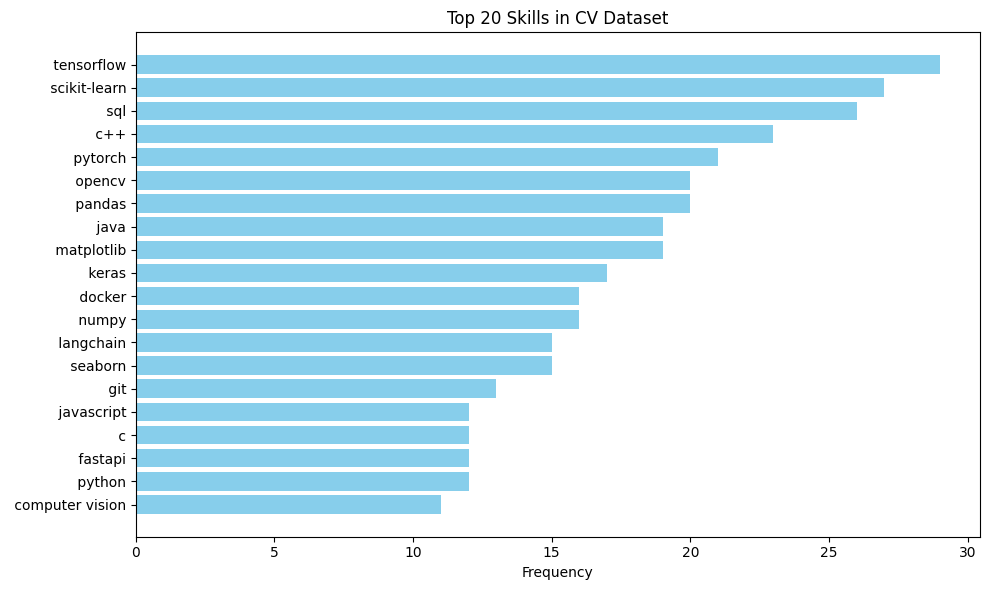

In [45]:
#which skills are most common
import matplotlib.pyplot as plt

skills, counts = zip(*top_skills)
plt.figure(figsize=(10,6))
plt.barh(skills[::-1], counts[::-1], color='skyblue')  # reversed for descending order
plt.title("Top 20 Skills in CV Dataset")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [46]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

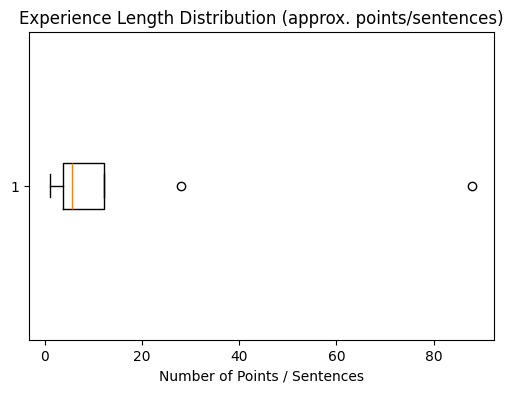

In [47]:
plt.figure(figsize=(6,4))
plt.boxplot(experience_counts, vert=False)
plt.title("Experience Length Distribution (approx. points/sentences)")
plt.xlabel("Number of Points / Sentences")
plt.show()

Concentration: Most people provide a short description of their experience, typically between 4 and 12 sentences.

Skewness: The data is right-skewed, meaning while most descriptions are short, there are a few individuals who provide exceptionally long explanations (the outliers).

# Identify important features

From your CVs, the key evaluation features usually are:

Skills → technical, soft skills, certifications
Experience → years, roles, relevant projects
Education → degree, university, specialization
Projects → scope, technologies used, impact

In [48]:
# diagnostic tool that identifies:
# Missing or incomplete information
# Very short or ambiguous entries
# Inconsistent or rare skills
# Limitations of keyword-based matching
# Lack of explainability
# Possible demographic biases
from collections import Counter
from collections import Counter
import pandas as pd

def detect_cv_challenges(cvs_df):
    challenges = []

    # Missing or incomplete data
    missing_summary = cvs_df.isnull().sum()
    for col, count in missing_summary.items():
        if count > 0:
            challenges.append(f"Missing data in '{col}': {count} entries")

    # Ambiguous text / very short fields
    for col in ['skills', 'experience', 'education', 'projects']:
        if col in cvs_df.columns:
            short_count = (cvs_df[col].fillna('').str.len() < 10).sum()
            if short_count > 0:
                challenges.append(f"Very short or empty '{col}' entries: {short_count} CVs")

    # Skill inconsistencies
    all_skills = cvs_df['skills'].dropna().str.split(',').sum()
    skill_counter = Counter([s.strip().lower() for s in all_skills])
    rare_skills = [skill for skill, freq in skill_counter.items() if freq == 1]
    if rare_skills:
        challenges.append(f"Inconsistent or unique skill names (may indicate typos or variations): {rare_skills[:5]}...")

    #  Keyword / semantic limitation
    challenges.append("Keyword-based matching may miss semantic similarity between skills and job requirements")

    # Explainability limitation
    challenges.append("Ranking may lack explainability; cannot clearly justify why a CV scores higher than another")

    # optional: potential bias
    if 'gender' in cvs_df.columns:
        bias_summary = cvs_df['gender'].value_counts().to_dict()
        challenges.append(f"Potential gender bias: {bias_summary}")
    if 'university' in cvs_df.columns:
        uni_summary = cvs_df['university'].value_counts().to_dict()
        challenges.append(f"Potential university bias: {dict(list(uni_summary.items())[:5])}...")

    return challenges

In [49]:
challenges_detected = detect_cv_challenges(cvs_df)

print("Detected Challenges:\n")
for c in challenges_detected:
    print("-", c)

Detected Challenges:

- Very short or empty 'skills' entries: 4 CVs
- Very short or empty 'experience' entries: 4 CVs
- Very short or empty 'education' entries: 1 CVs
- Very short or empty 'projects' entries: 6 CVs
- Inconsistent or unique skill names (may indicate typos or variations): ['.\n• developed a multi-stage computerized assessment system (oral interviews', 'bilingual written tests', 'and prac-\ntical exams) to baseline skills', 'track progress', 'and validate learning gains. built a data collection pipeline to inform\ntailored instruction and demonstrate program efficacy.\n• recruited']...
- Keyword-based matching may miss semantic similarity between skills and job requirements
- Ranking may lack explainability; cannot clearly justify why a CV scores higher than another


# phase 4:Implementation

In [50]:
#required libraries
!pip install sentence-transformers pandas
!pip install PyMuPDF python-docx

In [70]:
# ---------- Define Job Requirements ----------
job_desc_ai_text = """
AI Engineer (Multimodal & LLM Systems)
Responsibilities: Develop AI models for resume understanding (NLP), interview analysis (text/audio/video), candidate ranking, LLM pipelines, fairness-aware ML, XAI components, optimize models.
Required Skills: Python, ML/DL, NLP, Transformers, embeddings, PyTorch, TensorFlow, Hugging Face, RAG pipelines, model evaluation.
Preferred: Multimodal AI, fairness-aware ML, explainable AI (LIME/SHAP), deployment experience.
"""

job_desc_fs_text = """
Full Stack Engineer (AI-Driven Platforms)
Responsibilities: Develop frontend interfaces (React), backend APIs (Node.js/Django/FastAPI), integrate AI models, manage structured/unstructured DBs, build scalable pipelines, ensure performance/security.
Required Skills: JavaScript/TypeScript, backend frameworks, REST APIs, DB design, system architecture.
Preferred: ML/AI integration, Docker, cloud deployment (AWS/Azure), vector DBs, real-time/scalable pipelines.
"""


In [71]:
# ---------- Initialize Model ----------
model = SentenceTransformer('all-MiniLM-L6-v2')  # lightweight, fast

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [72]:
# ---------- Compute Embeddings ----------
# Job description embeddings
job_embeddings = {role: model.encode(text, convert_to_tensor=True)
                  for role, text in job_descriptions.items()}

In [73]:
def combine_cv_text(row):
    return " ".join([str(row['skills']), str(row['experience']), str(row['projects'])])

cvs_df['combined_text'] = cvs_df.apply(combine_cv_text, axis=1)
cvs_embeddings = model.encode(cvs_df['combined_text'].tolist(), convert_to_tensor=True)

In [74]:
scores = {}
for role, job_emb in job_embeddings.items():
    similarity = util.cos_sim(cvs_embeddings, job_emb)  # cosine similarity
    scores[role] = similarity.squeeze().tolist()

In [75]:
# Add scores to DataFrame
cvs_df['AI_Engineer_score'] = scores['AI Engineer']
cvs_df['Full_Stack_score'] = scores['Full Stack Engineer']


In [76]:
# ---------- Ranking ----------
cvs_df['AI_Engineer_rank'] = cvs_df['AI_Engineer_score'].rank(ascending=False, method='min')
cvs_df['Full_Stack_rank'] = cvs_df['Full_Stack_score'].rank(ascending=False, method='min')

# Demonstrate Results

In [77]:
from sentence_transformers import util

def top_matching_sections(cv_text, job_text, top_n=3):
    """Return top N matching phrases for explainability."""
    cv_sentences = cv_text.split('.')
    job_embedding = model.encode(job_text, convert_to_tensor=True)
    cv_embeddings = model.encode(cv_sentences, convert_to_tensor=True)
    cosine_scores = util.cos_sim(cv_embeddings, job_embedding).squeeze()
    top_idx = cosine_scores.topk(top_n).indices.tolist()
    return [cv_sentences[i].strip() for i in top_idx]

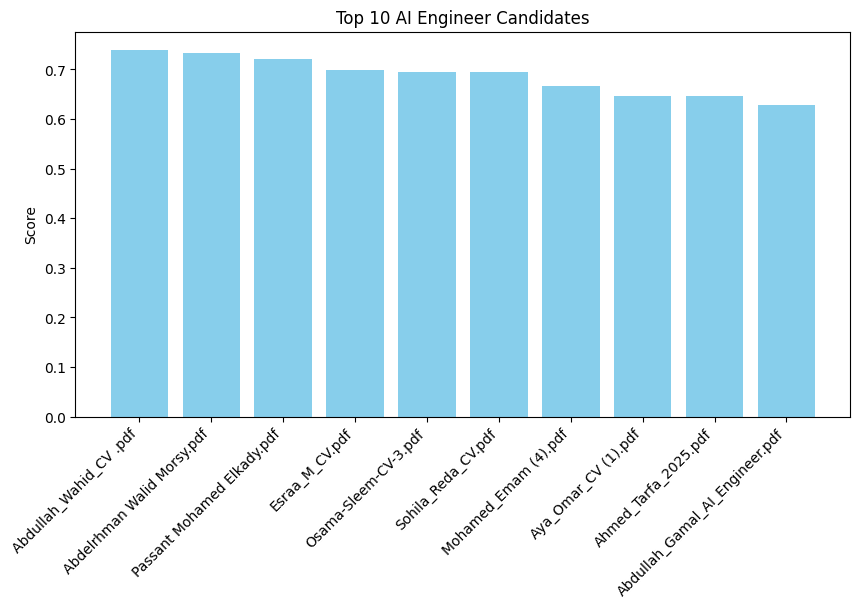

In [78]:
import matplotlib.pyplot as plt

top_ai = cvs_df.sort_values(by='AI_Engineer_score', ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_ai['file_name'], top_ai['AI_Engineer_score'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 AI Engineer Candidates")
plt.ylabel("Score")
plt.show()

Top Skills Frequency
Show which skills are most common among top candidates

In [79]:
from collections import Counter

top_skills_list = []
for text in top_ai['skills']:
    if isinstance(text, str):
        top_skills_list.extend([s.strip() for s in text.split(',')])
Counter(top_skills_list).most_common(10)

[('scikit-learn', 9),
 ('tensorflow', 8),
 ('c++', 7),
 ('pandas', 5),
 ('numpy', 5),
 ('docker', 5),
 ('sql', 5),
 ('object detection', 4),
 ('opencv', 4),
 ('keras', 4)]

For each top candidate,  I showed  which part of the CV contributed most to the score:

Skills matched
Projects matched
Experience phrases matched

In [80]:
print(cvs_df.columns)

Index(['skills', 'experience', 'education', 'projects', 'file_name',
       'combined_text', 'AI_Engineer_score', 'Full_Stack_score',
       'AI_Engineer_rank', 'Full_Stack_rank'],
      dtype='object')


In [81]:
# --- Show top candidate per role ---
def show_top_candidate(role_col, job_text):
    top = cvs_df.sort_values(by=role_col, ascending=False).iloc[0]
    cv_text = {'skills': top['skills'], 'experience': top['experience'], 'projects': top['projects']}
    matches = get_top_matching_sections(cv_text, job_text, top_n=3)
    print(f"\nCandidate: {top['file_name']}")
    print(f"Score: {top[role_col]:.2f}")
    print("Matched Sections:")
    print(f"- Skills: {', '.join(matches['skills'])}")
    print(f"- Experience: {', '.join(matches['experience'])}")
    print(f"- Projects: {', '.join(matches['projects'])}")

print("=== Top AI Engineer Candidate ===")
show_top_candidate('AI_Engineer_score', job_descriptions['AI Engineer'])

print("\n=== Top Full Stack Engineer Candidate ===")
show_top_candidate('Full_Stack_score', job_descriptions['Full Stack Engineer'])

=== Top AI Engineer Candidate ===

Candidate: Abdullah_Wahid_CV .pdf
Score: 0.74
Matched Sections:
- Skills: ai frameworks: pytorch, ai agents, programming languages: python
- Experience: trainee artificial intelligence, machine learning intern @ digital hub                                                                                         06/2023 – 09/2023, machine learning engineer @ sss
- Projects: tools & technologies: pytorch, tools & technologies: pytorch, tools & technologies: pytorch

=== Top Full Stack Engineer Candidate ===

Candidate: Youssef Faisal - CV.pdf
Score: 0.66
Matched Sections:
- Skills: frameworks: node, cloud & devops: (ec2, professional: agile/scrum methodologies
- Experience: • back end developer – link development, devops workflows, docker
- Projects: architecture, built a production-focused backend using nestjs (onion architecture) integrating local llms (ollama llama3, dockerized services and deployed on aws ec2 with github actions ci


# phase 6

In [82]:
# Show top N candidates with highlighted contributing sections
def show_top_candidates(role_score_col, job_text, top_n=3):
    top_candidates = cvs_df.sort_values(by=role_score_col, ascending=False).head(top_n)

    print(f"=== Top {top_n} Candidates for {role_score_col.replace('_', ' ')} ===\n")

    for idx, row in top_candidates.iterrows():
        cv_text = {
            'skills': row.get('skills', ''),
            'experience': row.get('experience', ''),
            'projects': row.get('projects', '')
        }

        matched_sections = get_top_matching_sections(cv_text, job_text, top_n=3)

        print(f"Candidate: {row['file_name']}")
        print(f"Score: {row[role_score_col]:.2f}")
        print("Matched Sections:")
        print(f"- Skills: {', '.join(matched_sections['skills']) if matched_sections['skills'] else 'N/A'}")
        print(f"- Experience: {', '.join(matched_sections['experience']) if matched_sections['experience'] else 'N/A'}")
        print(f"- Projects: {', '.join(matched_sections['projects']) if matched_sections['projects'] else 'N/A'}")
        print("-" * 50)

def get_top_matching_sections(cv_text, job_text, top_n=3):
    """
    For a CV, return the top matching phrases in skills, experience, and projects
    that contributed most to similarity with the job description.
    """
    matched_sections = {}
    model_embed_job = model.encode(job_text, convert_to_tensor=True)

    sections = ['skills', 'experience', 'projects']
    for sec in sections:
        sec_text = cv_text.get(sec, "")
        if not sec_text:
            matched_sections[sec] = []
            continue

        # Split by common separators
        phrases = re.split(r'[.,;\n]', sec_text)
        phrases = [p.strip() for p in phrases if len(p.strip()) > 2]

        if len(phrases) == 0:
            matched_sections[sec] = []
            continue

        # Embed phrases
        sec_embeddings = model.encode(phrases, convert_to_tensor=True)
        cosine_scores = util.cos_sim(sec_embeddings, model_embed_job).squeeze()

        # Safe top N extraction
        topk_result = cosine_scores.topk(min(top_n, len(phrases)))
        top_idx = topk_result.indices

        # Ensure top_idx is always a list
        if isinstance(top_idx, int):
            top_idx = [top_idx]
        elif top_idx.dim() == 0:  # 0-dim tensor
            top_idx = [top_idx.item()]
        else:
            top_idx = top_idx.tolist()

        matched_sections[sec] = [phrases[i] for i in top_idx]

    return matched_sections

# Usage
job_desc_ai = job_descriptions['AI Engineer']
job_desc_fs = job_descriptions['Full Stack Engineer']
show_top_candidates('AI_Engineer_score', job_desc_ai, top_n=3)
show_top_candidates('Full_Stack_score', job_desc_fs, top_n=3)

=== Top 3 Candidates for AI Engineer score ===

Candidate: Abdullah_Wahid_CV .pdf
Score: 0.74
Matched Sections:
- Skills: ai frameworks: pytorch, ai agents, programming languages: python
- Experience: trainee artificial intelligence, machine learning intern @ digital hub                                                                                         06/2023 – 09/2023, machine learning engineer @ sss
- Projects: tools & technologies: pytorch, tools & technologies: pytorch, tools & technologies: pytorch
--------------------------------------------------
Candidate: Abdelrhman Walid Morsy.pdf
Score: 0.73
Matched Sections:
- Skills: gcp ai platform, • ai expert certificate — school of ai, ai agents & automation: ai agent development (crewai)
- Experience: computer vision, learning, in nlp
- Projects: and collaborate with professionals shaping the future of intelligent systems
--------------------------------------------------
Candidate: Passant Mohamed Elkady.pdf
Score: 0.72
Matched

In [83]:
import pandas as pd

# Assuming cvs_df already has the score columns
# Example columns: 'file_name', 'AI_Engineer_score', 'Full_Stack_score'

# Create a new DataFrame for comparison
summary_df = cvs_df[['file_name', 'AI_Engineer_score', 'Full_Stack_score']].copy()

# Determine which role the candidate ranks higher in
def higher_rank(row):
    if row['AI_Engineer_score'] > row['Full_Stack_score']:
        return 'AI Engineer'
    elif row['Full_Stack_score'] > row['AI_Engineer_score']:
        return 'Full Stack'
    else:
        return 'Tie'

summary_df['Higher Rank'] = summary_df.apply(higher_rank, axis=1)

# Sort by AI Engineer score descending (or Full Stack if you prefer)
summary_df = summary_df.sort_values(by=['AI_Engineer_score', 'Full_Stack_score'], ascending=False)

# Show top 5 for example
print(summary_df.head(5))

# Optional: display as a nice table if using Jupyter
from IPython.display import display
display(summary_df.head()

                     file_name  AI_Engineer_score  Full_Stack_score  \
66      Abdullah_Wahid_CV .pdf           0.739030          0.467057   
67  Abdelrhman Walid Morsy.pdf           0.732447          0.458249   
77  Passant Mohamed Elkady.pdf           0.720818          0.390391   
68              Esraa_M_CV.pdf           0.698086          0.376539   
18        Osama-Sleem-CV-3.pdf           0.695000          0.375012   

    Higher Rank  
66  AI Engineer  
67  AI Engineer  
77  AI Engineer  
68  AI Engineer  
18  AI Engineer  


,file_name,AI_Engineer_score,Full_Stack_score,Higher Rank
66,Abdullah_Wahid_CV .pdf,0.739030,0.467057,AI Engineer
67,Abdelrhman Walid Morsy.pdf,0.732447,0.458249,AI Engineer
77,Passant Mohamed Elkady.pdf,0.720818,0.390391,AI Engineer
68,Esraa_M_CV.pdf,0.698086,0.376539,AI Engineer
18,Osama-Sleem-CV-3.pdf,0.695000,0.375012,AI Engineer
